# V1 Response MLP

Train a multilayer perceptron to classify `v1_response_grid` examples. The default setup filters to `7 uA` and predicts `channel` only.

In [110]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.neural_network import MLPClassifier

In [111]:
FILE_PATH = Path(r"C:\Users\alber\OneDrive\Desktop\Rice\Semesters\Spring 2026\ELEC502 - Neural Machine Learning 1\Project\LGN11_20260328_day_pointer_v1_trial_response_arrays (3).h5")

with h5py.File(FILE_PATH, "r") as f:
    channel = np.asarray(f["/channel"]).astype(int).reshape(-1)
    current_uA = np.asarray(f["/current_uA"]).astype(float).reshape(-1)
    v1_response_grid = np.asarray(f["/v1_response_grid"], dtype=float)
    v1_mask = np.asarray(f["/v1_mask"]).astype(bool) if "/v1_mask" in f else None

if v1_response_grid.shape[0] != channel.size and v1_response_grid.shape[-1] == channel.size:
    v1_response_grid = np.transpose(v1_response_grid, (2, 1, 0))

grid_shape = v1_response_grid.shape[1:]
if v1_mask is not None and v1_mask.shape != grid_shape and v1_mask.T.shape == grid_shape:
    v1_mask = v1_mask.T

print("Loaded:", FILE_PATH)
print("v1_response_grid shape:", v1_response_grid.shape)
print("has v1_mask:", v1_mask is not None)
print("n unique channels:", len(np.unique(channel)))
print("unique currents:", np.unique(current_uA))

Loaded: C:\Users\alber\OneDrive\Desktop\Rice\Semesters\Spring 2026\ELEC502 - Neural Machine Learning 1\Project\LGN11_20260328_day_pointer_v1_trial_response_arrays (3).h5
v1_response_grid shape: (1980, 27, 35)
has v1_mask: True
n unique channels: 11
unique currents: [0. 2. 3. 4. 5. 7.]


In [112]:
# Data selection
TARGET_CURRENT_UA = 7.0
LABEL_MODE = "channel"  # "channel" or "channel_current"

# Normalization settings
NORMALIZE_RANGE = (-0.95, 0.95)

# Split settings
TEST_SIZE = 0.25
RANDOM_STATE = 42

keep = np.isclose(current_uA, TARGET_CURRENT_UA)
X_raw = v1_response_grid[keep]
channel_kept = channel[keep]
current_kept = current_uA[keep]
original_indices = np.flatnonzero(keep)

if LABEL_MODE == "channel":
    label_strings = np.array([f"ch_{ch}" for ch in channel_kept])
elif LABEL_MODE == "channel_current":
    label_strings = np.array([f"ch_{ch}_uA_{cur:g}" for ch, cur in zip(channel_kept, current_kept)])
else:
    raise ValueError(f"Unsupported LABEL_MODE: {LABEL_MODE}")

class_names, y = np.unique(label_strings, return_inverse=True)
valid_pixel_mask = np.any(np.isfinite(X_raw), axis=0)
X = np.nan_to_num(X_raw[:, valid_pixel_mask], nan=0.0)


# Normalizing data
dataset_min = np.min(X)
dataset_max = np.max(X)
target_min, target_max = NORMALIZE_RANGE

if np.isclose(dataset_max, dataset_min):
    X = np.full_like(X, (target_min + target_max) / 2.0)
else:
    X = target_min + (X - dataset_min) * (target_max - target_min) / (dataset_max - dataset_min)


def split_indices_train_test_per_class(y, test_size, random_state):
    rng = np.random.default_rng(random_state)
    train_idx = []
    test_idx = []

    for cls in np.unique(y):
        cls_idx = np.flatnonzero(y == cls)
        cls_idx = rng.permutation(cls_idx)
        n_cls = len(cls_idx)

        if n_cls < 2:
            raise ValueError(
                f"Class {cls} ({class_names[cls]}) has only {n_cls} samples. "
                "Need at least 2 samples to place one in train and one in test."
            )

        n_test = max(1, int(round(n_cls * test_size)))
        if n_cls - n_test < 1:
            n_test = n_cls - 1

        test_idx.extend(cls_idx[:n_test])
        train_idx.extend(cls_idx[n_test:])

    train_idx = rng.permutation(np.array(train_idx, dtype=int))
    test_idx = rng.permutation(np.array(test_idx, dtype=int))
    return train_idx, test_idx


train_idx, test_idx = split_indices_train_test_per_class(
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]
test_original_indices = original_indices[test_idx]

counts = np.bincount(y, minlength=len(class_names))
train_counts = np.bincount(y_train, minlength=len(class_names))
test_counts = np.bincount(y_test, minlength=len(class_names))

print(f"Filtered to current {TARGET_CURRENT_UA:g} uA")
print("Samples kept:", len(y))
print("Flattened finite-pixel feature count:", X.shape[1])
print("Classes:", class_names.tolist())
print("Counts per class:", {name: int(count) for name, count in zip(class_names, counts)})
print("Dataset min/max before normalization:", float(dataset_min), float(dataset_max))
print("Normalized range:", float(np.min(X)), float(np.max(X)))
print("Train / test:", len(y_train), len(y_test))
print("Train counts:", {name: int(count) for name, count in zip(class_names, train_counts)})
print("Test counts:", {name: int(count) for name, count in zip(class_names, test_counts)})

Filtered to current 7 uA
Samples kept: 330
Flattened finite-pixel feature count: 945
Classes: ['ch_114', 'ch_122', 'ch_16', 'ch_18', 'ch_28', 'ch_32', 'ch_50', 'ch_84', 'ch_86', 'ch_87', 'ch_96']
Counts per class: {'ch_114': 30, 'ch_122': 30, 'ch_16': 30, 'ch_18': 30, 'ch_28': 30, 'ch_32': 30, 'ch_50': 30, 'ch_84': 30, 'ch_86': 30, 'ch_87': 30, 'ch_96': 30}
Dataset min/max before normalization: -0.1286889910697937 0.37038862705230713
Normalized range: -0.95 0.95
Train / test: 242 88
Train counts: {'ch_114': 22, 'ch_122': 22, 'ch_16': 22, 'ch_18': 22, 'ch_28': 22, 'ch_32': 22, 'ch_50': 22, 'ch_84': 22, 'ch_86': 22, 'ch_87': 22, 'ch_96': 22}
Test counts: {'ch_114': 8, 'ch_122': 8, 'ch_16': 8, 'ch_18': 8, 'ch_28': 8, 'ch_32': 8, 'ch_50': 8, 'ch_84': 8, 'ch_86': 8, 'ch_87': 8, 'ch_96': 8}


In [113]:
# MLP configuration
HIDDEN_LAYER_SIZE = 128
ACTIVATION = "tanh"          # "identity", "logistic", "tanh", "relu"
ONLINE_LEARNING = True       # True -> one update per sample, False -> one update per mini-batch
INITIAL_WEIGHT_RANGE = (-0.1, 0.1)
LEARNING_RATE_INIT = 0.001
MOMENTUM = 0.8
MAX_EPOCHS = 150
PATIENCE = 20
MIN_DELTA = 1e-4
STOPPING_METRIC = "test_accuracy"  # "test_accuracy" or "test_loss"
MONITOR_FREQUENCY = 242  # evaluate metrics, update history, and check stopping every N learning steps

In [114]:
def build_mlp(random_state=RANDOM_STATE):
    batch_size = 1 if ONLINE_LEARNING else min(32, len(y_train))
    return MLPClassifier(
        hidden_layer_sizes=(HIDDEN_LAYER_SIZE,),
        activation=ACTIVATION,
        solver="sgd",
        learning_rate="constant",
        learning_rate_init=LEARNING_RATE_INIT,
        momentum=MOMENTUM,
        batch_size=batch_size,
        shuffle=True,
        max_iter=1,
        warm_start=False,
        random_state=random_state,
    )


def apply_custom_initialization(model, X_ref, y_ref, classes):
    model.partial_fit(X_ref, y_ref, classes=classes)
    rng = np.random.default_rng(RANDOM_STATE)
    low, high = INITIAL_WEIGHT_RANGE

    for i, W in enumerate(model.coefs_):
        model.coefs_[i] = rng.uniform(low, high, size=W.shape)
        model.intercepts_[i] = rng.uniform(low, high, size=model.intercepts_[i].shape)


def snapshot_weights(model):
    return [w.copy() for w in model.coefs_], [b.copy() for b in model.intercepts_]


def restore_weights(model, weights):
    coefs, intercepts = weights
    model.coefs_ = [w.copy() for w in coefs]
    model.intercepts_ = [b.copy() for b in intercepts]


def evaluate_model(model):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    train_loss = model.loss_
    test_loss = -np.mean(np.log(np.clip(model.predict_proba(X_test)[np.arange(len(y_test)), y_test], 1e-12, 1.0)))
    return {
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "train_loss": train_loss,
        "test_loss": test_loss,
    }


def append_history(history, step, epoch, metrics):
    history["step"].append(step)
    history["epoch"].append(epoch)
    for key in ["train_accuracy", "test_accuracy", "train_loss", "test_loss"]:
        history[key].append(metrics[key])


def should_monitor(step, total_steps):
    return (step % MONITOR_FREQUENCY == 0) or (step == total_steps)


def plot_training_history(history):
    steps = history["step"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(steps, history["train_accuracy"], label="train")
    axes[0].plot(steps, history["test_accuracy"], label="test", alpha=0.8)
    axes[0].set_xlabel("Learning step")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"Accuracy monitored every {MONITOR_FREQUENCY} steps")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(steps, history["train_loss"], label="train")
    axes[1].plot(steps, history["test_loss"], label="test")
    axes[1].set_xlabel("Learning step")
    axes[1].set_ylabel("Loss")
    axes[1].set_title(f"Loss monitored every {MONITOR_FREQUENCY} steps")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def plot_confusions(model, class_names):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ConfusionMatrixDisplay(
        confusion_matrix(y_train, y_train_pred, labels=np.arange(len(class_names))),
        display_labels=class_names,
    ).plot(ax=axes[0], xticks_rotation=45, colorbar=False)
    axes[0].set_title(f"Train confusion matrix\nacc={accuracy_score(y_train, y_train_pred):.3f}")

    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_test_pred, labels=np.arange(len(class_names))),
        display_labels=class_names,
    ).plot(ax=axes[1], xticks_rotation=45, colorbar=False)
    axes[1].set_title(f"Test confusion matrix\nacc={accuracy_score(y_test, y_test_pred):.3f}")
    plt.tight_layout()
    plt.show()


def show_misclassified_examples(model, target_pred_label=None, max_examples=12, cmap="plasma"):
    y_test_pred = model.predict(X_test)
    mis_idx = np.flatnonzero(y_test_pred != y_test)

    if target_pred_label is not None:
        target_class = np.where(class_names == target_pred_label)[0]
        if len(target_class) == 0:
            raise ValueError(f"Unknown target_pred_label: {target_pred_label}")
        mis_idx = mis_idx[y_test_pred[mis_idx] == target_class[0]]

    if len(mis_idx) == 0:
        print("No matching misclassified examples found.")
        return

    shown_idx = mis_idx[:max_examples]
    original_idx = test_original_indices[shown_idx]
    imgs = v1_response_grid[original_idx]

    finite = imgs[np.isfinite(imgs)]
    if finite.size == 0:
        vmin, vmax = -1.0, 1.0
    else:
        lo, hi = np.quantile(finite, [0.02, 0.98])
        vmax = max(abs(lo), abs(hi))
        if vmax == 0 or not np.isfinite(vmax):
            vmax = 1.0
        vmin = -vmax

    ncols = min(4, len(shown_idx))
    nrows = int(np.ceil(len(shown_idx) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols + 1.2, 4 * nrows), squeeze=False)
    axes = axes.ravel()
    last_im = None

    for ax, local_i, global_i in zip(axes, shown_idx, original_idx):
        img = np.ma.masked_invalid(v1_response_grid[global_i])
        last_im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
        if v1_mask is not None:
            ax.contour(v1_mask.astype(float), levels=[0.5], colors="w", linewidths=1.0)
        ax.set_title(
            f"orig {global_i}\ntrue={class_names[y_test[local_i]]}\npred={class_names[y_test_pred[local_i]]}",
            fontsize=9,
        )
        ax.axis("off")

    for ax in axes[len(shown_idx):]:
        ax.axis("off")

    fig.subplots_adjust(right=0.90, wspace=0.15, hspace=0.28)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.70])
    fig.colorbar(last_im, cax=cbar_ax, label="dF/F")
    plt.show()

    print("Misclassified original indices:", original_idx.tolist())

In [115]:
classes = np.arange(len(class_names))
model = build_mlp()

init_indices = []
for cls in classes:
    cls_idx = np.flatnonzero(y_train == cls)
    if len(cls_idx) == 0:
        raise ValueError(f"No training examples found for class {cls} ({class_names[cls]}).")
    init_indices.append(cls_idx[0])

X_init = X_train[init_indices]
y_init = y_train[init_indices]
apply_custom_initialization(model, X_init, y_init, classes)

history = {
    "step": [],
    "epoch": [],
    "train_accuracy": [],
    "test_accuracy": [],
    "train_loss": [],
    "test_loss": [],
}

best_score = -np.inf
best_weights = snapshot_weights(model)
checks_without_improvement = 0
learning_step = 0
rng = np.random.default_rng(RANDOM_STATE)
total_steps = MAX_EPOCHS * (len(y_train) if ONLINE_LEARNING else 1)

for epoch in range(1, MAX_EPOCHS + 1):
    if ONLINE_LEARNING:
        order = rng.permutation(len(y_train))
        for idx in order:
            model.partial_fit(X_train[idx:idx + 1], y_train[idx:idx + 1], classes=classes)
            learning_step += 1

            if not should_monitor(learning_step, total_steps):
                continue

            metrics = evaluate_model(model)
            append_history(history, learning_step, epoch, metrics)

            if STOPPING_METRIC == "test_accuracy":
                current_score = metrics["test_accuracy"]
                improved = current_score > best_score + MIN_DELTA
            elif STOPPING_METRIC == "test_loss":
                current_score = -metrics["test_loss"]
                improved = current_score > best_score + MIN_DELTA
            else:
                raise ValueError(f"Unsupported STOPPING_METRIC: {STOPPING_METRIC}")

            if improved:
                best_score = current_score
                best_weights = snapshot_weights(model)
                checks_without_improvement = 0
            else:
                checks_without_improvement += 1

            if checks_without_improvement >= PATIENCE:
                print(f"Early stopping at epoch {epoch}, step {learning_step}")
                restore_weights(model, best_weights)
                print("Best test score:", best_score)
                break
        else:
            continue
        break
    else:
        model.partial_fit(X_train, y_train, classes=classes)
        learning_step += 1

        if not should_monitor(learning_step, total_steps):
            continue

        metrics = evaluate_model(model)
        append_history(history, learning_step, epoch, metrics)

        if STOPPING_METRIC == "test_accuracy":
            current_score = metrics["test_accuracy"]
            improved = current_score > best_score + MIN_DELTA
        elif STOPPING_METRIC == "test_loss":
            current_score = -metrics["test_loss"]
            improved = current_score > best_score + MIN_DELTA
        else:
            raise ValueError(f"Unsupported STOPPING_METRIC: {STOPPING_METRIC}")

        if improved:
            best_score = current_score
            best_weights = snapshot_weights(model)
            checks_without_improvement = 0
        else:
            checks_without_improvement += 1

        if checks_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch}, step {learning_step}")
            break

restore_weights(model, best_weights)
print("Best test score:", best_score)
print("Monitoring frequency:", MONITOR_FREQUENCY)

Early stopping at epoch 66, step 15972
Best test score: 0.7272727272727273
Best test score: 0.7272727272727273
Monitoring frequency: 242


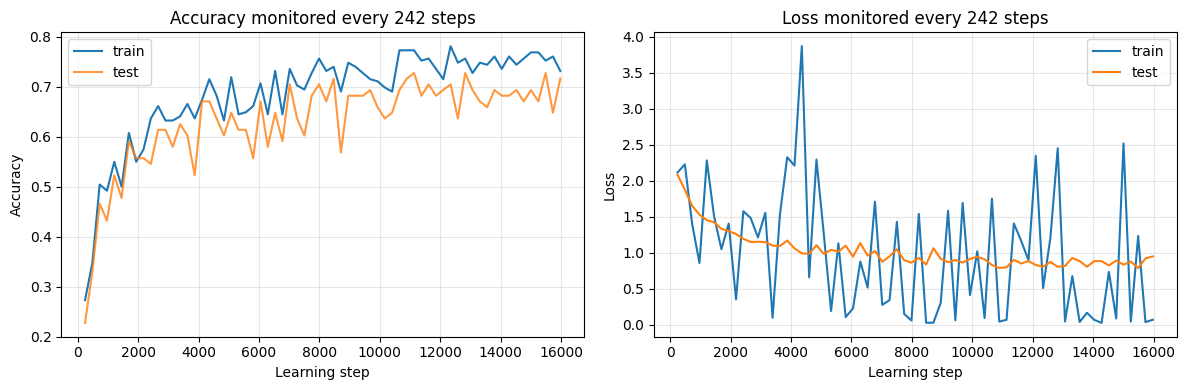

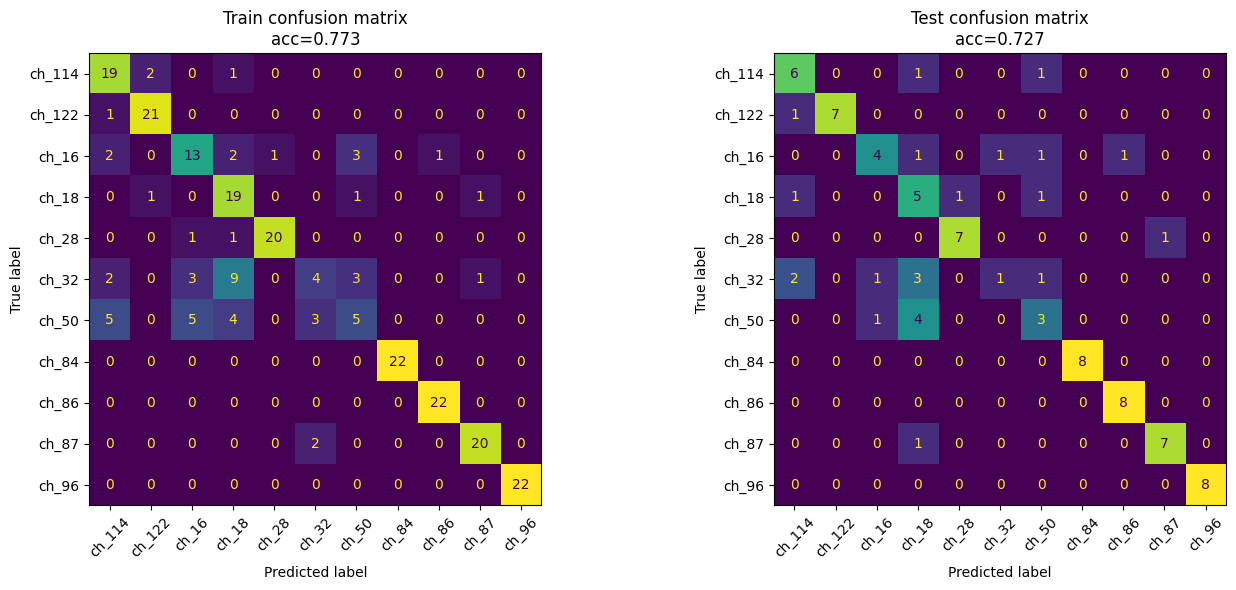

Final train accuracy: 0.7727272727272727
Final test accuracy: 0.7272727272727273


In [116]:
plot_training_history(history)
plot_confusions(model, class_names)
print("Final train accuracy:", accuracy_score(y_train, model.predict(X_train)))
print("Final test accuracy:", accuracy_score(y_test, model.predict(X_test)))

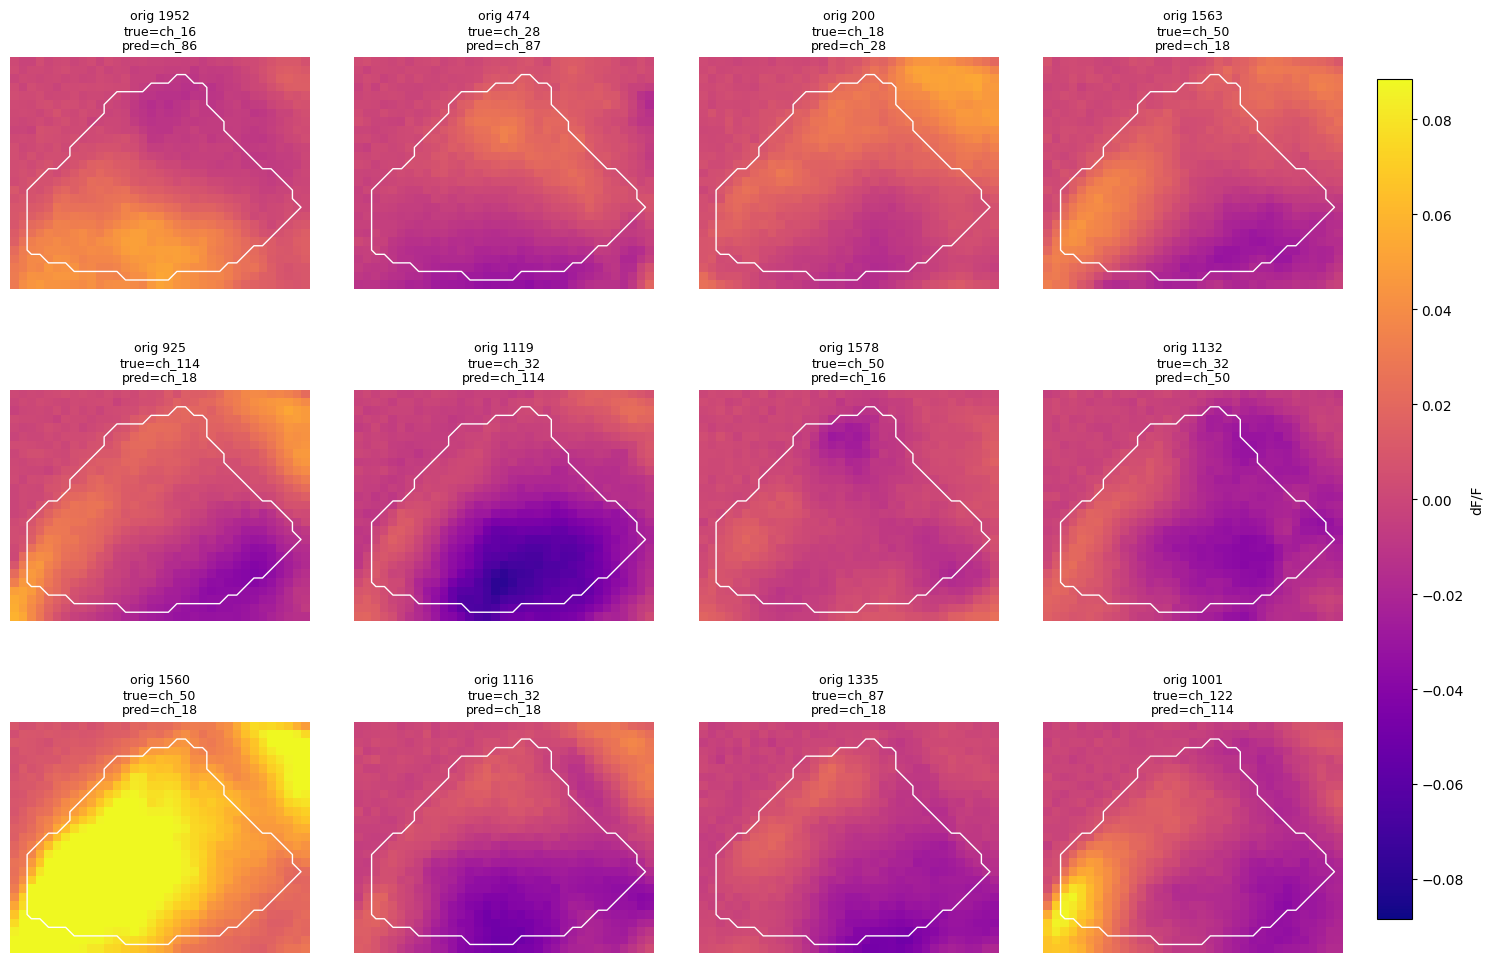

Misclassified original indices: [1952, 474, 200, 1563, 925, 1119, 1578, 1132, 1560, 1116, 1335, 1001]


In [117]:
# Show misclassified test examples.
# Example: all misclassified samples
show_misclassified_examples(model, max_examples=12, cmap="plasma")

# Example: only samples misclassified AS ch16
# show_misclassified_examples(model, target_pred_label="ch_16", max_examples=12, cmap="plasma")